In [1]:
import numpy as np
import matplotlib.pyplot as plt

def getDVH(dose_arr, mask, binsize=0.1, dmax=None):
    '''
    Calculate DVH
    dose_arr: dose array
    mask: mask of GTV/OAR
    binsize: bin size of the histogram, default 0.1
    dmax: maximum dose value for DVH calculation, using max(dose_arr)*110% if not given
    return: values of dose and DVH
    '''
    dosevalues = dose_arr[mask>0]
    
    if dmax is None:
        dmax = np.amax(dosevalues)*1.0
    hist, bin_edges = np.histogram(dosevalues, bins=np.arange(0,dmax,binsize))
    DVH = np.append(1, 1 - np.cumsum(hist)/len(dosevalues)) * 100
    return bin_edges, DVH

def NPZ2DVH(roi_dict, needed_mask, ref_ptv_name = None, ref_dose = 70, bin_size = 4, with_plt = True, save_plt_path = None):
    

    if roi_dict['dose'].max() > 200:
        dose_arr = roi_dict['dose'] * roi_dict['dose_scale'] 
    
    if dose_arr.max() < 10:
        dose_arr = 80 / dose_arr.max()  * dose_arr

    if ref_ptv_name is not None:
        ptv = roi_dict[ref_ptv_name]

        scale = ref_dose / np.percentile(dose_arr[ptv > 0.5], 2) 
    
        dose_arr = dose_arr * scale

    dvh_dict = {}

    for key in needed_mask:
        if roi_dict[key].max() == 0:
            continue
        #try:
        bin_edges_dose, DVH_dose = getDVH(dose_arr, roi_dict[key], binsize= bin_size, dmax=None)
        dvh_dict[key]  = {'dose': bin_edges_dose.tolist(), 'dvh': DVH_dose.tolist()}

        if with_plt:
            plt.plot(bin_edges_dose, DVH_dose,  label=key)
        # except:
        #     print ('erro in ', key)
        #     continue
    if with_plt:
        plt.xlabel('Dose (Gy)')
        plt.ylabel('Volume (%)')  
        plt.legend(bbox_to_anchor=(1.01, 1.01))
        plt.show()
        
    return dvh_dict

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


# 1. load the data in the npz format

In [43]:
data_path = 'data/HNC_001+A4Ac+MOS_25934.npz'
data_npz = np.load(data_path, allow_pickle=True)
data_dict = dict(data_npz)['arr_0'].item()

In [44]:
data_dict.keys()

dict_keys(['SpinalCord_05', 'BrainStem_03', 'Submand-PTV', 'Posterior_Neck', 'PharynxConst', 'Submandibular', 'Parotids', 'Parotids-PTV', 'PTVLowOPT', 'PTVMidOPT', 'PTV_Total', 'Lungs', 'RingPTVLow', 'RingPTVMid', 'RingPTVHigh', 'SubmandR-PTV', 'SubmandL-PTV', 'Thyroid-PTV', 'Larynx-PTV', 'OCavity-PTV', 'Mandible-PTV', 'PharConst-PTV', 'ParotdCon-PTV', 'ParotdIps-PTV', 'Low-Mid', 'Mid-High', 'High-Mid', 'ParotidIpsi', 'ParotidContra', 'Larynx', 'PTV_High', 'PTV_Mid', 'PTV_Low', 'BODY', 'PTV70', 'PTV 59.4', 'PTV 50.4', 'CTV 59.4', 'CTV 50.4', 'Brachial Plexus Left', 'Brachial Plexus Right', 'Brain', 'Brainstem', 'Brainstem Dahanca', 'Cochlea Left', 'Cochlea Right', 'Esophagus', 'Eye Globe Left', 'Eye Globe Right', 'Glottis', 'Glottis Dahanca', 'Inferior Pharyngeal Constrictor Muscle', 'Lips', 'Lung Left', 'Lung Right', 'Mandible', 'Middle Pharyngeal Constrictor Muscle', 'Optic Chiasm', 'Optic Nerve Left', 'Optic Nerve Right', 'Oral Cavity', 'Parotid Gland Left', 'Parotid Gland Right', '

## show the patient in Eclipse system 

<img src="./figs/eclipse.png">

[104. 114.  41.]


Text(0.5, 1.0, 'View from Coronal plane')

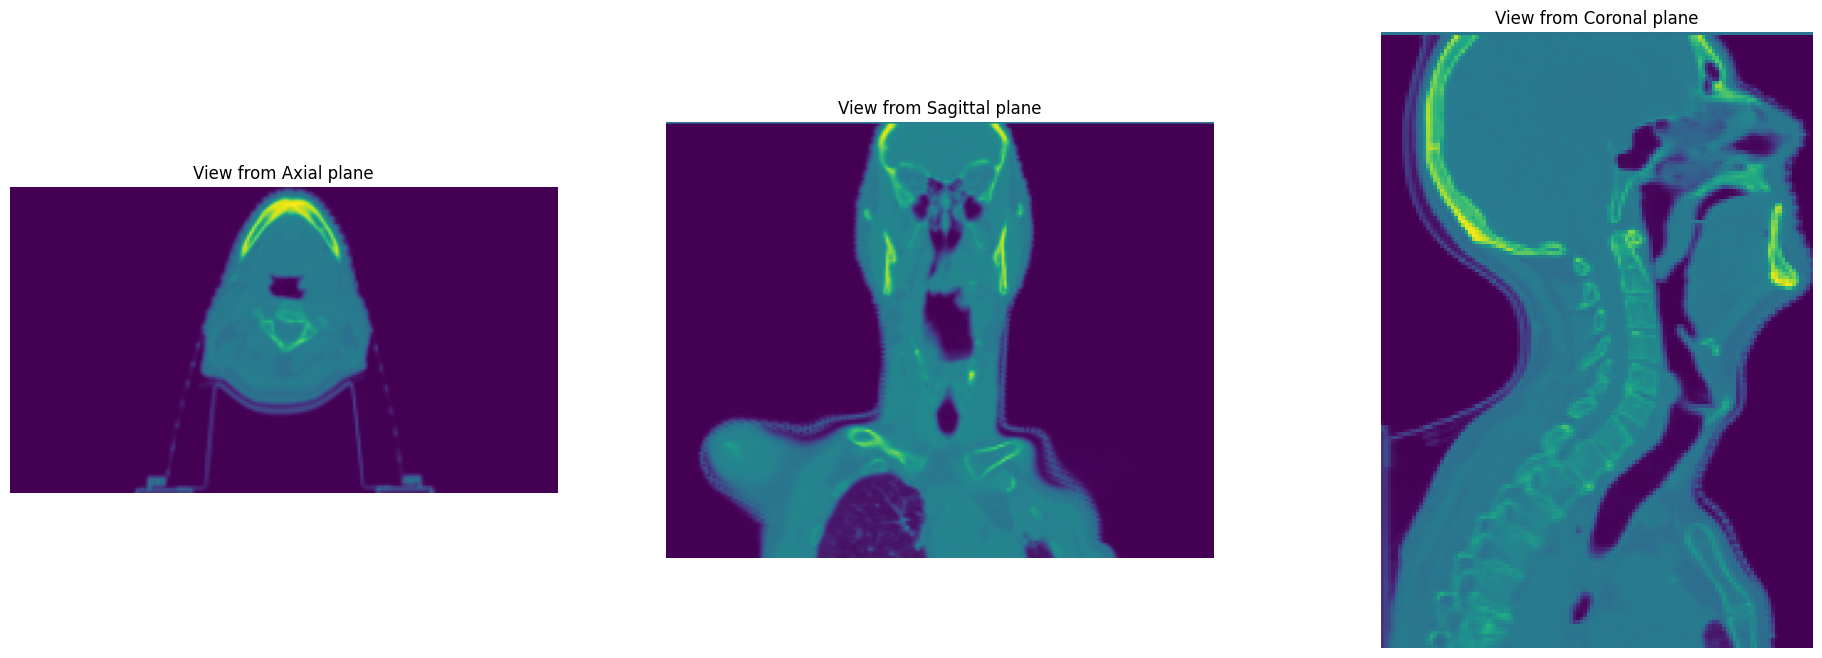

In [61]:

print (data_dict['isocenter'])

fig = plt.figure(figsize=(24, 8))

ax1 = fig.add_subplot(131)
ax1.imshow(data_dict['img'][int(data_dict['isocenter'][0])])
ax1.axis('off')
ax1.set_title('View from Axial plane')

ax2 = fig.add_subplot(132)
ax2.imshow(data_dict['img'][::-1, int(data_dict['isocenter'][2]), :])
ax2.axis('off')
ax2.set_title('View from Sagittal plane')

ax3 = fig.add_subplot(133)
ax3.imshow(data_dict['img'][::-1, ::-1, int(data_dict['isocenter'][1])])
ax3.axis('off')
ax3.set_title('View from Coronal plane')


Text(0.5, 1.0, 'View from Coronal plane')

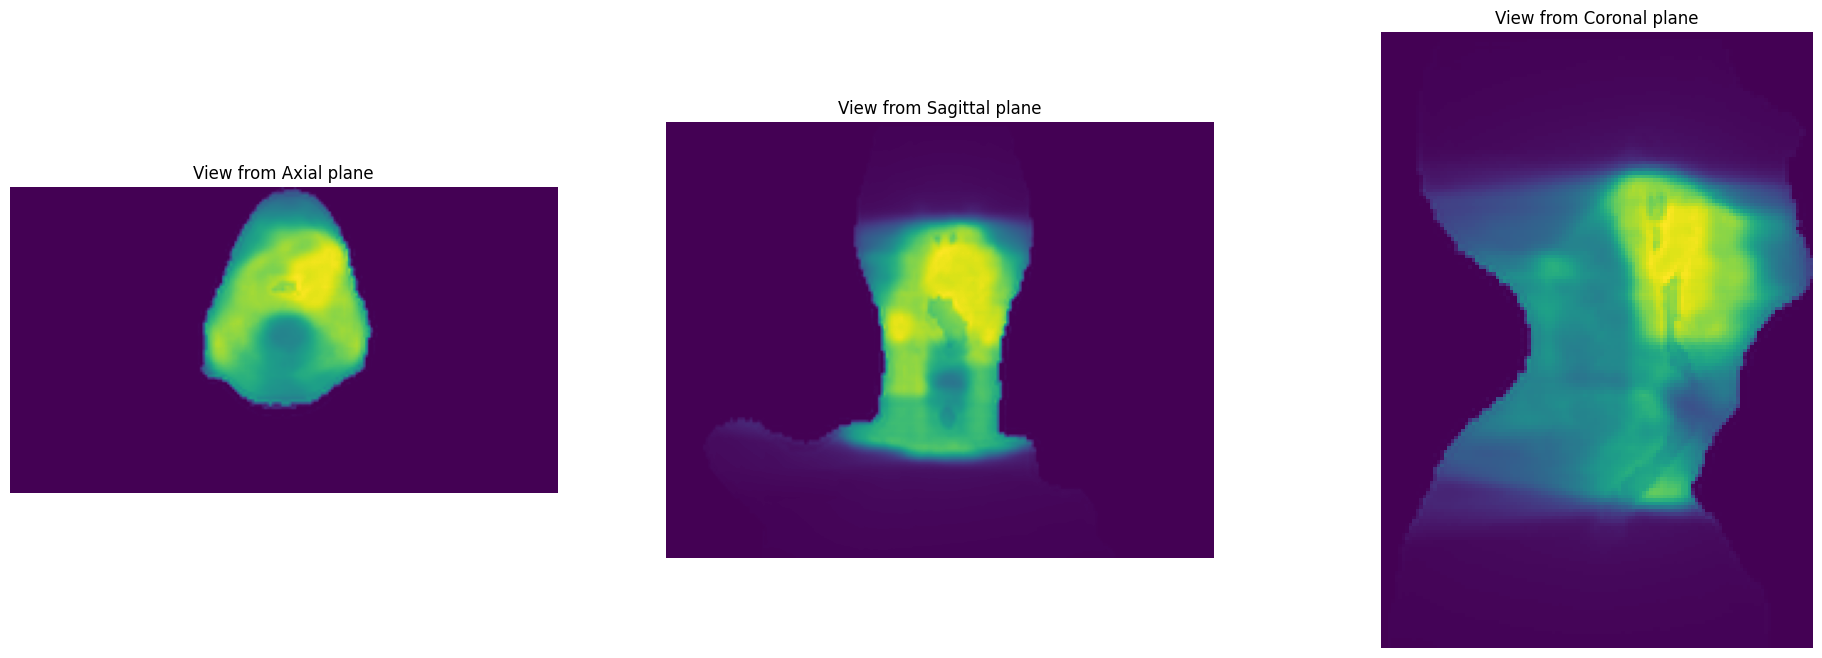

In [62]:
fig = plt.figure(figsize=(24, 8))

dose = data_dict['dose'] 
#dose = np.flip(data_dict['dose'], axis=0)
#dose = np.flip(dose, axis=2)

ax1 = fig.add_subplot(131)
ax1.imshow(dose[ int(data_dict['isocenter'][0])])
ax1.axis('off')
ax1.set_title('View from Axial plane')

ax2 = fig.add_subplot(132)
ax2.imshow(dose[::-1, int(data_dict['isocenter'][2]), :])
ax2.axis('off')
ax2.set_title('View from Sagittal plane')

ax3 = fig.add_subplot(133)
ax3.imshow(dose[::-1, ::-1, int(data_dict['isocenter'][1])])
ax3.axis('off')
ax3.set_title('View from Coronal plane')

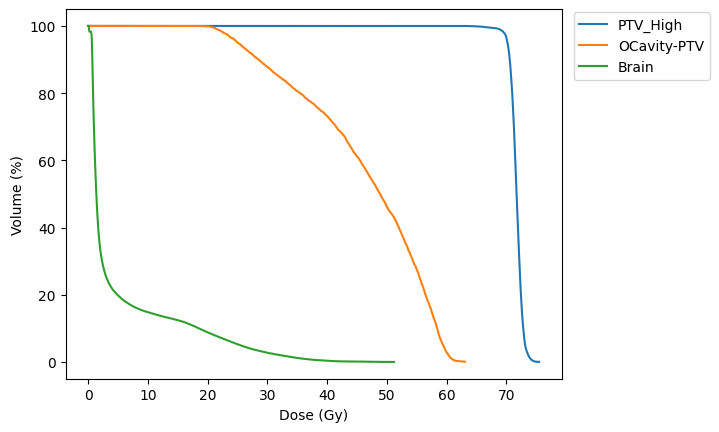

In [48]:
dvh_dict = NPZ2DVH(data_dict, needed_mask = ['PTV_High', 'OCavity-PTV', 'Brain'], ref_ptv_name = None, ref_dose = None, bin_size = 0.1, with_plt = True, save_plt_path = None)